In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# параметры
states = ['E', '5', 'I']
nucleotides = ['A', 'C', 'G', 'T']

pi = {'E': 1.0, '5': 0.0, 'I': 0.0}

A = {
    'E': {'E': 0.9, '5': 0.1, 'I': 0.0},
    '5': {'E': 0.0, '5': 0.0, 'I': 1.0},
    'I': {'E': 0.0, '5': 0.0, 'I': 0.9},
}

B = {
    'E': {'A': 0.25, 'C': 0.25, 'G': 0.25, 'T': 0.25},
    '5': {'A': 0.05, 'C': 0.0,  'G': 0.95, 'T': 0.0 },
    'I': {'A': 0.4,  'C': 0.1,  'G': 0.1,  'T': 0.4 },
}

In [3]:
# логарифмические функции (вспомогательные)
NEG_INF = float('-inf')

def safe_log(x):
    return np.log(x) if x > 0 else NEG_INF

def log_sum(a, b):
    if a == NEG_INF: return b
    if b == NEG_INF: return a
    return max(a, b) + np.log1p(np.exp(-abs(a - b)))

log_pi = {s: safe_log(pi[s]) for s in states}
log_A  = {s: {t: safe_log(A[s][t]) for t in states} for s in states}
log_B  = {s: {n: safe_log(B[s][n]) for n in nucleotides} for s in states}

In [4]:
# витерби
def viterbi(obs):
    T = len(obs)
    delta = [{s: NEG_INF for s in states} for _ in range(T)]
    psi   = [{s: None    for s in states} for _ in range(T)]

    for s in states:
        delta[0][s] = log_pi[s] + log_B[s][obs[0]]

    for t in range(1, T):
        for s in states:
            best_val, best_prev = NEG_INF, None
            for p in states:
                v = delta[t-1][p] + log_A[p][s]
                if v > best_val:
                    best_val, best_prev = v, p
            delta[t][s] = best_val + log_B[s][obs[t]]
            psi[t][s]   = best_prev

    last = max(states, key=lambda s: delta[T-1][s])
    path = [last]
    for t in range(T-1, 0, -1):
        path.append(psi[t][path[-1]])
    path.reverse()
    return path, delta[T-1][last]

In [5]:
# forward
def forward(obs):
    T = len(obs)
    alpha = [{s: NEG_INF for s in states} for _ in range(T)]

    for s in states:
        alpha[0][s] = log_pi[s] + log_B[s][obs[0]]

    for t in range(1, T):
        for s in states:
            lsum = NEG_INF
            for p in states:
                lsum = log_sum(lsum, alpha[t-1][p] + log_A[p][s])
            alpha[t][s] = lsum + log_B[s][obs[t]]

    log_prob = NEG_INF
    for s in states:
        log_prob = log_sum(log_prob, alpha[T-1][s])
    return alpha, log_prob

In [6]:
# backward
def backward(obs):
    T = len(obs)
    beta = [{s: NEG_INF for s in states} for _ in range(T)]

    for s in states:
        beta[T-1][s] = 0.0  # log(1) = 0

    for t in range(T-2, -1, -1):
        for s in states:
            lsum = NEG_INF
            for n in states:
                lsum = log_sum(lsum, log_A[s][n] + log_B[n][obs[t+1]] + beta[t+1][n])
            beta[t][s] = lsum
    return beta

In [7]:
# апостериорное декодирование
def posterior(obs):
    alpha, log_prob = forward(obs)
    beta = backward(obs)
    T = len(obs)
    gamma = [{s: np.exp(alpha[t][s] + beta[t][s] - log_prob) for s in states}
             for t in range(T)]
    return gamma, log_prob

**2.1**

In [16]:
# витерби на по-ть из статьи
seq = list("CTTCATGTGAAAGCAGACGTAAGTCA")

path, log_p = viterbi(seq)
print("витерби")
print("по-ть: ", "".join(seq))
print("найденный путь:", "".join(path))
print("путь из статьи:EEEEEEEEEEEEEEEEEE5IIIIIII")
print("совпадения:", "".join(path) == "EEEEEEEEEEEEEEEEEE5IIIIIII") #False, т.е. не совпадают

витерби
по-ть:  CTTCATGTGAAAGCAGACGTAAGTCA
найденный путь: EEEEEEEEEEEEEEEEEEEEEEEEEE
путь из статьи:EEEEEEEEEEEEEEEEEE5IIIIIII
совпадения: False


**2.2**

In [18]:
# полная вероятность (forward)
_, log_prob = forward(seq)
print(f"forward")
print(f"log P = {log_prob:.6f}")
print(f"P = {np.exp(log_prob):.6e}")

forward
log P = -37.674845
P = 4.345329e-17


**2.3**

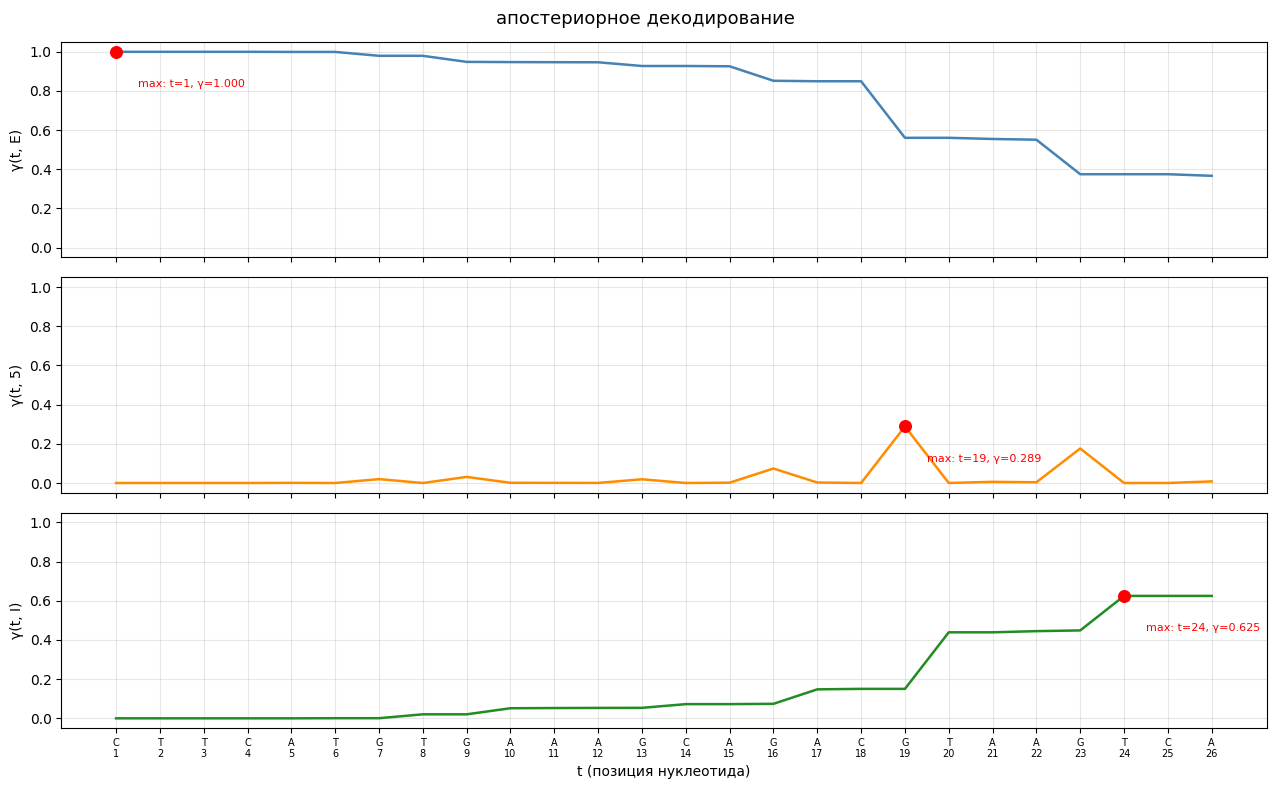

In [20]:
# графики (максимумы найдены и указаны на графиках)
gamma, _ = posterior(seq)
T = len(seq)
t_axis = list(range(1, T + 1))

gamma_E = [gamma[t]['E'] for t in range(T)]
gamma_5 = [gamma[t]['5'] for t in range(T)]
gamma_I = [gamma[t]['I'] for t in range(T)]

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
fig.suptitle("апостериорное декодирование", fontsize=13)

for ax, g, label, color in zip(
    axes,
    [gamma_E, gamma_5, gamma_I],
    ['E', '5', 'I'],
    ['steelblue', 'darkorange', 'forestgreen']
):
    ax.plot(t_axis, g, color=color, linewidth=1.8)
    ax.set_ylabel(f"γ(t, {label})", fontsize=10)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(t_axis)
    ax.set_xticklabels([f"{seq[i]}\n{i+1}" for i in range(T)], fontsize=7)
    ax.grid(True, alpha=0.3)

    max_t = int(np.argmax(g))
    ax.scatter([t_axis[max_t]], [g[max_t]], color='red', zorder=5, s=70)
    ax.annotate(
        f"max: t={t_axis[max_t]}, γ={g[max_t]:.3f}",
        xy=(t_axis[max_t], g[max_t]),
        xytext=(t_axis[max_t] + 0.5, g[max_t] - 0.18),
        fontsize=8, color='red'
    )

axes[-1].set_xlabel("t (позиция нуклеотида)", fontsize=10)
plt.tight_layout()
plt.savefig("posterior_decoding.png", dpi=150)
plt.show()